Exp 4:
Customer Churn Prediction: Develop a model to predict customer
churn in a subscription-based business.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df=pd.read_csv('/content/drive/MyDrive/python-ml-lab/exp2_3_4/customer_churn_dataset.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Tenure_Months,SubscriptionType,MonthlyCharges,TotalCharges,PaymentMethod,SupportTickets,ContractType,Churn
0,CUST1000,Male,49,54,Standard,99.33,4912.77,Net Banking,1,Two Year,0
1,CUST1001,Female,56,8,Standard,12.01,604.59,Debit Card,2,Two Year,0
2,CUST1002,Male,66,27,Basic,57.62,2019.39,Cash,4,Two Year,0
3,CUST1003,Male,69,27,Premium,97.08,4848.88,Credit Card,7,Two Year,0
4,CUST1004,Male,49,34,Standard,54.69,4334.26,Credit Card,9,One Year,1


In [4]:
df.shape

(200, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    object 
 1   Gender            200 non-null    object 
 2   Age               200 non-null    int64  
 3   Tenure_Months     200 non-null    int64  
 4   SubscriptionType  200 non-null    object 
 5   MonthlyCharges    200 non-null    float64
 6   TotalCharges      200 non-null    float64
 7   PaymentMethod     200 non-null    object 
 8   SupportTickets    200 non-null    int64  
 9   ContractType      200 non-null    object 
 10  Churn             200 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 17.3+ KB


In [6]:
df_encoded = pd.get_dummies(df.drop(columns=['CustomerID']), drop_first=True)



In [7]:
#Split Features & Target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']


In [8]:
X

,Age,Tenure_Months,MonthlyCharges,TotalCharges,SupportTickets,Gender_Male,SubscriptionType_Premium,SubscriptionType_Standard,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Net Banking,PaymentMethod_UPI,ContractType_One Year,ContractType_Two Year
0,49,54,99.33,4912.77,1,True,False,True,False,False,True,False,False,True
1,56,8,12.01,604.59,2,False,False,True,False,True,False,False,False,True
2,66,27,57.62,2019.39,4,True,False,False,False,False,False,False,False,True
3,69,27,97.08,4848.88,7,True,True,False,True,False,False,False,False,True
4,49,34,54.69,4334.26,9,True,False,True,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,47,48,21.47,1897.88,2,False,False,False,False,True,False,False,False,True
196,55,21,90.19,1390.19,3,False,True,False,False,False,False,True,True,False
197,55,39,12.62,3237.80,6,False,False,False,False,True,False,False,False,True
198,62,36,54.83,2073.23,0,True,False,True,True,False,False,False,False,True


In [9]:
y

,Churn
0,0
1,0
2,0
3,0
4,1
...,...
195,0
196,0
197,0
198,0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [11]:
#Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [12]:
#Predictions
y_pred = model.predict(X_test)


In [13]:

#accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy*100, 2), "%")

Model Accuracy: 75.0 %


In [14]:
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.29      0.29      0.29         7

    accuracy                           0.75        40
   macro avg       0.57      0.57      0.57        40
weighted avg       0.75      0.75      0.75        40



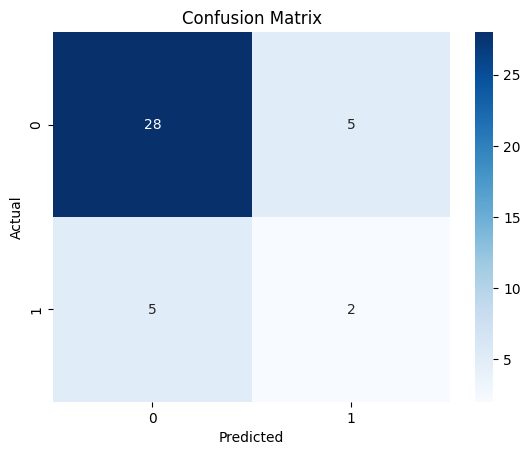

In [15]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


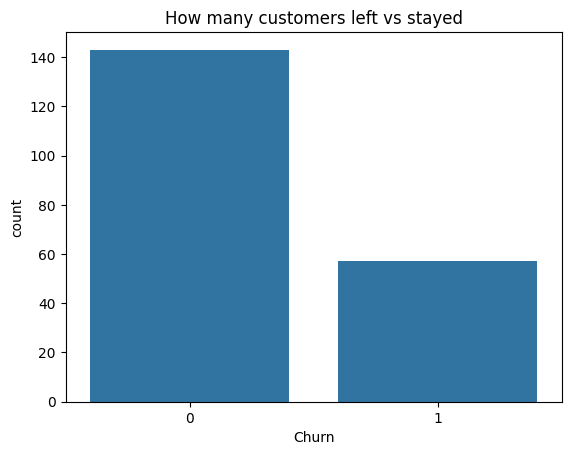

In [16]:
# Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("How many customers left vs stayed")
plt.show()


In [17]:
import pickle

# Save the trained model to a file
filename = 'logistic_regression_model.pkl'
pickle.dump(model, open(filename, 'wb'))

print(f"Model successfully saved as {filename}")

Model successfully saved as logistic_regression_model.pkl


The F1-score is a harmonic mean of precision and recall, providing a single metric that balances both. A higher F1-score indicates a better model, especially in cases where there's an imbalance between classes, like in churn prediction.